In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
raw_df = pd.read_csv("train.csv")
n = len(raw_df) // 3

In [3]:
raw_df.iloc[:n].to_csv("sales_part1.csv", index=False)
raw_df.iloc[n : 2 * n].to_excel("sales_part2.xlsx", index=False)
raw_df.iloc[2 * n :].to_json("sales_part3.json", orient="records")

In [4]:
df_csv = pd.read_csv("sales_part1.csv")
df_excel = pd.read_excel("sales_part2.xlsx")
df_json = pd.read_json("sales_part3.json")

In [5]:
df = pd.concat([df_csv, df_excel, df_json], ignore_index=True)

In [6]:
df.drop_duplicates(inplace=True)
df.dropna(subset=["Sales", "Order Date"], inplace=True)

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="mixed")
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month

In [8]:
print("Total Sales: $", round(df["Sales"].sum(), 2))
print("Average Order Value: $", round(df["Sales"].mean(), 2))

Total Sales: $ 2261536.78
Average Order Value: $ 230.77


In [9]:
category_sales = df.groupby("Category")["Sales"].sum()
print("\nSales by Category:\n", category_sales)


Sales by Category:
 Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


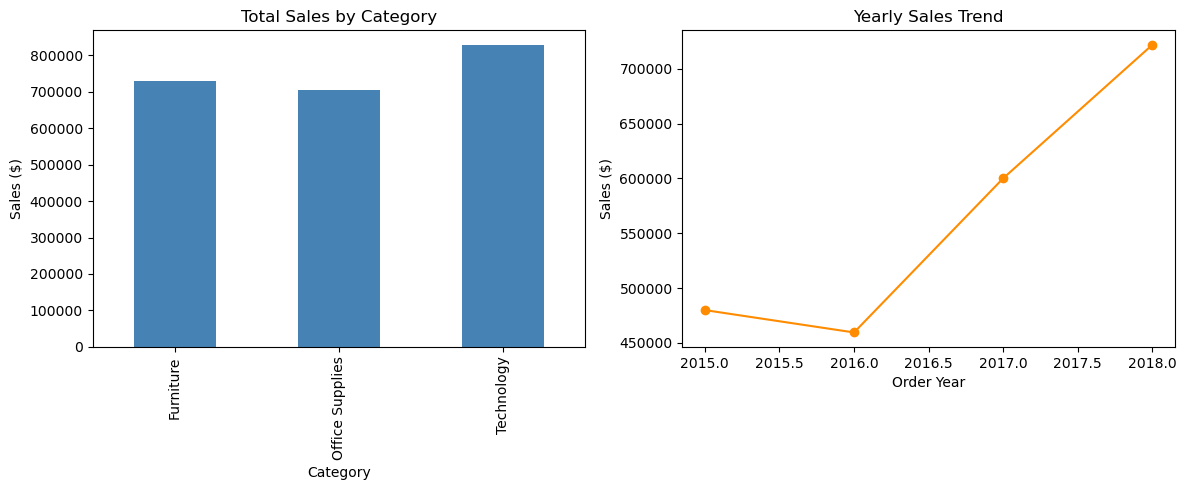

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

category_sales.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Sales ($)")

df.groupby("Order Year")["Sales"].sum().plot(
    kind="line", marker="o", ax=axes[1], color="darkorange"
)
axes[1].set_title("Yearly Sales Trend")
axes[1].set_ylabel("Sales ($)")

plt.tight_layout()
plt.show()